## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Figure 4: Benefits of leveraging HP flexibility in power systems.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

### Figure 4(a) - 4(f): Comparison of heat pump deployment levels

This section visualizes six heat pump deployment scenarios in a 2×3 subplot layout for a representative day.
For each scenario, the script aggregates conventional, EV, and HP demand, overlays the photovoltaic (PV) profile.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_32220\346633676.py:49: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_full = pd.date_range(start=datetime(year, 1, 1), periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_32220\346633676.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_time, end=end_time, freq='H')


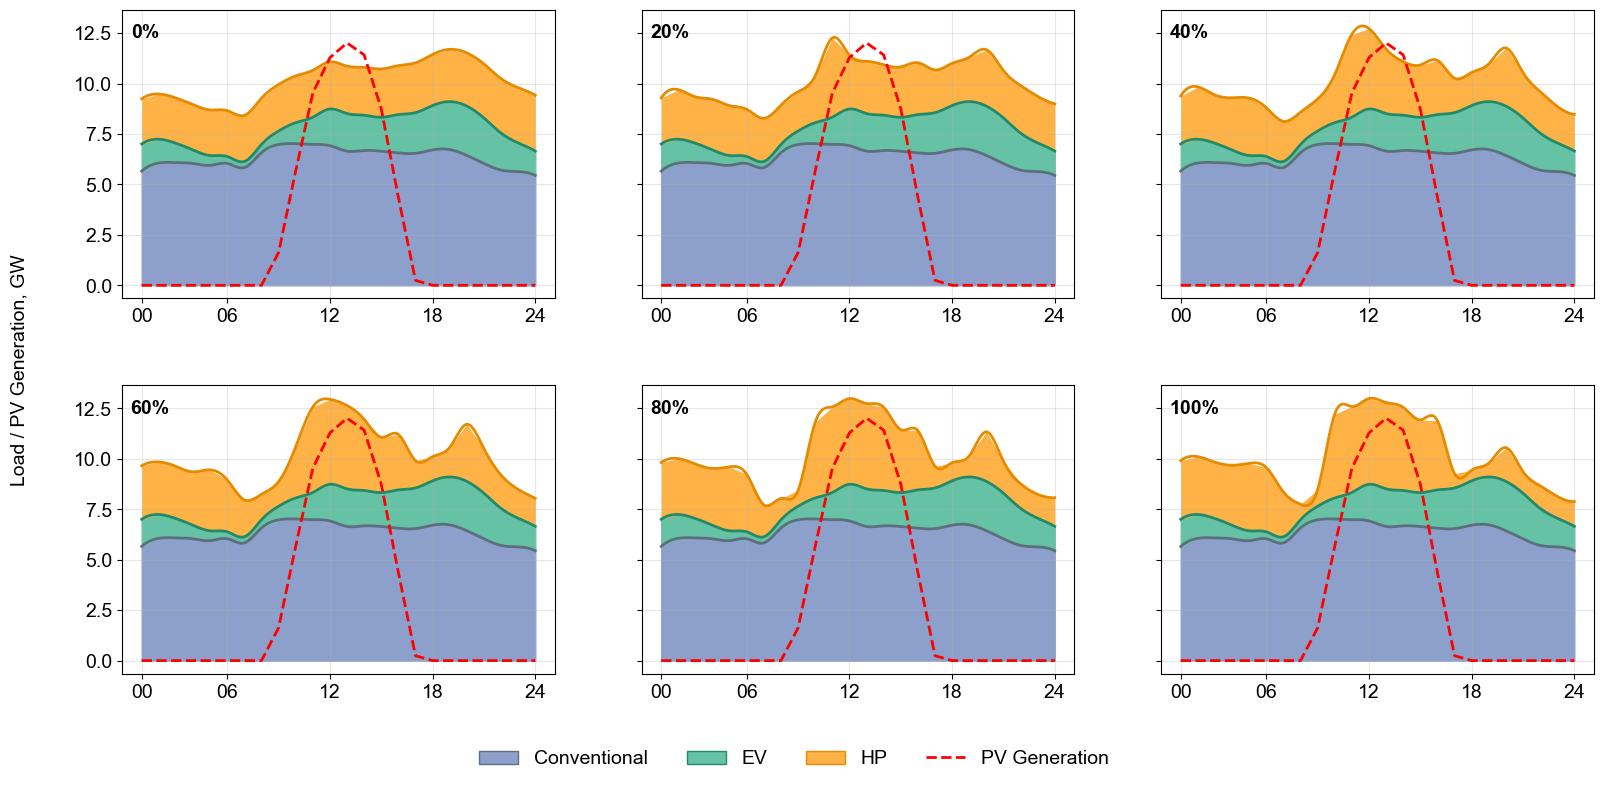

In [6]:
# =============================================================================
# This cell analyses and visualizes the results as shown in Fig.4(a) - Fig.4(f)
# =============================================================================


# === Six cases in 2x3 subplots; HP stacked on EV; Morandi palette; fixed 00-06-12-18-24; per-subplot editable text ===
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.interpolate import make_interp_spline
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl
from pathlib import Path

# ------------ Core parameters ------------
year = 2050
start_month = 1
start_day = 15
days_to_plot = 1

cases = ["case4e", "case4d", "case4c", "case4b", "case4a", "case3a"]

# Text shown in the upper-left corner of each subplot (editable individually)
subplot_texts = [
    "0%",
    "20%",
    "40%",
    "60%",
    "80%",
    "100%"
]

root = r"..\Output_data\power systems results"

# === Colors (Morandi Style) ===
fill_colors = {"conventional": '#8da0cb', "ev": '#66c2a5', "hp": '#ffb347'}
line_colors = {"conventional": '#5e6e7e', "ev": '#238a68', "hp": '#e68a00'}
pv_line_kwargs = dict(color='red', linestyle='--', linewidth=2.0)

# === Font sizes ===
title_fs     = 14
axis_label_fs= 14
tick_fs      = 14
legend_fs    = 14

# ------------ Time index ------------
index_full = pd.date_range(start=datetime(year, 1, 1), periods=8760, freq='H')
start_time = datetime(year, start_month, start_day)
end_time = start_time + timedelta(hours=24 * days_to_plot - 1)
time_index = pd.date_range(start=start_time, end=end_time, freq='H')

x_vals = np.arange(len(time_index))
x_smooth = np.linspace(x_vals.min(), x_vals.max(), 300)
t_smooth = pd.date_range(start=start_time, end=end_time, periods=300)

# === Fixed x-axis ticks: 00, 06, 12, 18, 24; the first and last ticks match the data range, and 06/12/18 are evenly spaced between them ===
xtick_labels = ["00", "06", "12", "18", "24"]
xtick_positions_idx = np.linspace(0, len(time_index) - 1, len(xtick_labels)).astype(int)
xtick_positions = [time_index[i] for i in xtick_positions_idx]

# ------------ Create the 2×3 canvas ------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.flatten()

# ------------ Loop over subplots ------------
for i, case in enumerate(cases):
    ax = axes[i]

    # === HP ===
    file_hp = fr"{root}\{case}\CentIv_{year}\0-LoadHeatPump_AfterShift_hourly_ALL_LP.csv"
    df_hp = pd.read_csv(file_hp, header=[0, 1, 2])
    df_hp = df_hp.dropna(how="all")
    df_hp = df_hp.drop(columns=df_hp.columns[0])
    df_hp = df_hp.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    hp_series = df_hp.sum(axis=1)
    hp_series.index = index_full

    # === Conventional & EV ===
    file_conv = fr"{root}\{case}\national_generation_and_capacity\0-demand_hourly_c_ch_{year}.csv"
    df_conv = pd.read_csv(file_conv)
    df_conv.index = index_full
    df_conv = df_conv[["idProfile", "idProfile_eMobility"]] / 1000.0
    df_conv.columns = ["conventional", "emobility"]

    # === PV (Alpine + Roof) ===
    file_pv = fr"{root}\{case}\national_generation_and_capacity\0-national_generation_hourly_gwh_c_ch_{year}.csv"
    df_pv = pd.read_csv(file_pv)
    df_pv.index = index_full
    pv_alpine = df_pv["PV Alpine"] if "PV Alpine" in df_pv.columns else 0.0
    pv_roof   = df_pv["PV Roof"]   if "PV Roof"   in df_pv.columns else 0.0
    pv_series = pv_alpine + pv_roof

    # --- Slice the selected time window ---
    conv = df_conv.loc[start_time:end_time, "conventional"].values
    ev   = df_conv.loc[start_time:end_time, "emobility"].values
    hp   = hp_series.loc[start_time:end_time].values / 1000.0
    pv   = pv_series.loc[start_time:end_time]

    # --- Build cumulative stacked series ---
    conv_cumsum = conv
    ev_cumsum   = conv_cumsum + ev
    hp_cumsum   = ev_cumsum + hp

    # --- Plot filled areas ---
    ax.fill_between(time_index, 0,           conv_cumsum, color=fill_colors["conventional"])
    ax.fill_between(time_index, conv_cumsum, ev_cumsum,   color=fill_colors["ev"])
    ax.fill_between(time_index, ev_cumsum,   hp_cumsum,   color=fill_colors["hp"],
                    edgecolor=line_colors["hp"], linewidth=0.0)

    # --- Plot smoothed outline curves ---
    for y_vals, key in zip([conv_cumsum, ev_cumsum, hp_cumsum], ["conventional", "ev", "hp"]):
        spl = make_interp_spline(x_vals, y_vals, k=3)
        ax.plot(t_smooth, spl(x_smooth), color=line_colors[key], linewidth=2.0)

    # --- Plot the PV reference line ---
    ax.plot(pv.index, pv.values, **pv_line_kwargs)

    # --- Configure axis ticks and grid ---
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=tick_fs)
    ax.tick_params(axis='y', labelsize=tick_fs)
    ax.grid(True, alpha=0.3)

    # === Add the upper-left subplot label (editable individually) ===
    ax.text(0.02, 0.95, subplot_texts[i], transform=ax.transAxes,
            ha='left', va='top', fontsize=title_fs, color='black', weight='bold')

# ------------ Shared legend for the full figure ------------
legend_elements = [
    Patch(facecolor=fill_colors["conventional"], edgecolor=line_colors["conventional"], label='Conventional'),
    Patch(facecolor=fill_colors["ev"], edgecolor=line_colors["ev"], label='EV'),
    Patch(facecolor=fill_colors["hp"], edgecolor=line_colors["hp"], label='HP'),
    Line2D([0], [0], **pv_line_kwargs, label='PV Generation')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), frameon=False, prop={'size': legend_fs})

# ------------ Add one shared y-axis label on the left ------------
plt.tight_layout(rect=[0.07, 0.05, 1, 0.95])
fig.text(0.01, 0.5, "Load / PV Generation, GW", va='center', rotation='vertical', fontsize=axis_label_fs)

plt.subplots_adjust(left=0.08, right=1, top=0.95, bottom=0.12, wspace=0.2, hspace=0.3)
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ======================= SVG export (keep text editable in Illustrator) =======================
# Keep SVG text as editable text rather than converting it to paths (editable in Illustrator)
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX rendering to avoid text-to-path conversion
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()


### Figure 4(g): Comparison of trading energy in a single year

This section compares trading energy volumnes across heat pump deployment scenarios for a selected year. 


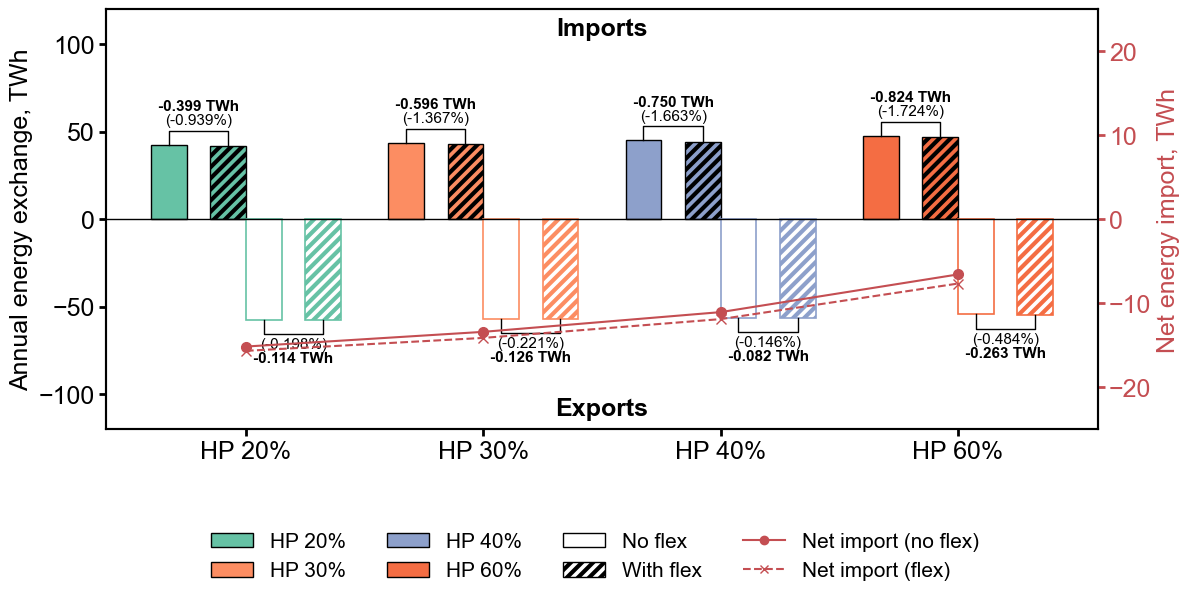

In [7]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 4(g)
# =====================================================================

import pandas as pd
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

# ========== Tick styling ==========
tick_font_size = 18

# Place these settings after the imports and before any plotting code
mpl.rcParams.update({
    'hatch.linewidth': 3.0,     # Key setting: increase hatch line width so it remains visible
    "patch.force_edgecolor": True,  # Force edge-color rendering (important)
    'path.simplify': False,
})

def apply_axis_style(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.tick_params(axis='x', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.tick_params(axis='x', labelsize=tick_font_size)

# ========== Scenario mapping ==========
hp_levels = ['HP 20%', 'HP 30%', 'HP 40%', 'HP 60%']
case_mapping = {
    'HP 20%': ('case1a0', 'case1a'),
    'HP 30%': ('case1b0', 'case1b'),
    'HP 40%': ('case1c0', 'case1c'),
    'HP 60%': ('case1d0', 'case1d'),
}

styles = {
    'HP 20%': '#66c2a5',
    'HP 30%': '#fc8d62',
    'HP 40%': '#8da0cb',
    'HP 60%': '#f46d43',
}


# ========== General settings ==========
base_path = r'..\Output_data\power systems results'
x = np.arange(len(hp_levels))
width = 0.3
line_color = '#C44E52'

# Offset constants
offset_line = 8
offset_text_delta = 8
offset_text_percent = 2

# ========== Create figure ==========
fig, ax = plt.subplots(figsize=(12, 5.5))
ax2 = ax.twinx()

# ========== Data processing and plotting ==========
net_nf_list = []
net_flex_list = []

for i, label in enumerate(hp_levels):
    case_nf, case_flex = case_mapping[label]
    color = styles[label]

    path_nf = fr'{base_path}\{case_nf}\national_generation_and_capacity\0-national_generation_annual_twh_c_ch.csv'
    path_flex = fr'{base_path}\{case_flex}\national_generation_and_capacity\0-national_generation_annual_twh_c_ch.csv'
    df_nf = pd.read_csv(path_nf).set_index('Row')
    df_flex = pd.read_csv(path_flex).set_index('Row')

    imp_nf = df_nf.loc['Imports'].iloc[3]
    exp_nf = df_nf.loc['Exports'].iloc[3]
    imp_flex = df_flex.loc['Imports'].iloc[3]
    exp_flex = df_flex.loc['Exports'].iloc[3]

    net_nf = imp_nf + exp_nf
    net_flex = imp_flex + exp_flex
    net_nf_list.append(net_nf)
    net_flex_list.append(net_flex)

    base = x[i]
    gap_outer = 0.10
    bar_width = width / 2

    # Correct the symmetric positions; apply gap_outer to the outermost sides
    offsets = [
        -1.5 * bar_width - gap_outer + bar_width/2 ,  # imp_nf
        -0.5 * bar_width + bar_width/2,              # imp_flex
         0.5 * bar_width + bar_width/2,              # exp_nf
         1.5 * bar_width + gap_outer + bar_width/2   # exp_flex
    ]
    centers = [base + off for off in offsets]

    center_imp_nf, center_imp_flex, center_exp_nf, center_exp_flex = centers

    ax.bar(center_imp_nf - bar_width/2, imp_nf, width=bar_width, color=color, edgecolor='black')
    ax.bar(center_imp_flex - bar_width/2, imp_flex, width=bar_width, color=color, edgecolor='black', hatch='///')
    ax.bar(center_exp_nf - bar_width/2, exp_nf, width=bar_width, color='white', edgecolor=color, linewidth=1.2)
    ax.bar(center_exp_flex - bar_width/2, exp_flex, width=bar_width, color='white', edgecolor=color, hatch='///', linewidth=1.2)

    # ========== Import annotations =====
    delta_imp = imp_flex - imp_nf
    percent_imp = (delta_imp / abs(imp_nf)) * 100 if imp_nf != 0 else 0
    delta_label_imp = f"{delta_imp:+.3f} TWh"
    percent_label_imp = f"({percent_imp:+.3f}%)"

    x1, x2 = center_imp_nf - bar_width/2, center_imp_flex - bar_width/2
    x_mid = (x1 + x2) / 2
    y1, y2 = imp_nf, imp_flex
    y_line = max(y1, y2) + offset_line

    ax.plot([x1, x1, x2, x2], [y1, y_line, y_line, y2], color='black', linewidth=1)
    ax.text(x_mid, y_line + offset_text_percent, percent_label_imp, ha='center', va='bottom', fontsize=11)
    ax.text(x_mid, y_line + offset_text_percent + offset_text_delta, delta_label_imp, ha='center', va='bottom', fontsize=11, fontweight='bold')

    # ========== Export annotations =====
    delta_exp = exp_flex - exp_nf
    percent_exp = (delta_exp / abs(exp_nf)) * 100 if exp_nf != 0 else 0
    delta_label_exp = f"{delta_exp:+.3f} TWh"
    percent_label_exp = f"({percent_exp:+.3f}%)"

    x1, x2 = center_exp_nf - bar_width/2, center_exp_flex - bar_width/2
    x_mid = (x1 + x2) / 2
    y1, y2 = exp_nf, exp_flex
    y_line = min(y1, y2) - offset_line

    ax.plot([x1, x1, x2, x2], [y1, y_line, y_line, y2], color='black', linewidth=1)
    ax.text(x_mid, y_line - offset_text_percent, percent_label_exp, ha='center', va='top', fontsize=11)
    ax.text(x_mid, y_line - offset_text_percent - offset_text_delta, delta_label_exp, ha='center', va='top', fontsize=11, fontweight='bold')

# ========== Net-import line plot ==========
ax2.plot(x, net_nf_list, color=line_color, marker='o', markersize=7, label='Net Import (No Flex)')
ax2.plot(x, net_flex_list, color=line_color, marker='x', linestyle='--', markersize=7, label='Net Import (Flex)')

# ========== Axis settings ==========
ax.set_xticks(x)
ax.set_xticklabels(hp_levels)
ax.set_ylabel('Annual energy exchange, TWh', fontsize=18)
ax.axhline(y=0, color='black', linewidth=1)
ax.grid(False)

ax2.set_ylabel('Net energy import, TWh', fontsize=18, color=line_color)
ax2.spines['right'].set_color(line_color)
ax2.tick_params(axis='y', colors=line_color)

apply_axis_style(ax)
apply_axis_style(ax2)

# Axis limits

ax.set_ylim(-120, 120)
ax2.set_ylim(-25, 25)


# ========== Legend ==========
legend_items = [
    Patch(facecolor='#66c2a5', label='HP 20%'),
    Patch(facecolor='#fc8d62', label='HP 30%'),
    Patch(facecolor='#8da0cb', label='HP 40%'),
    Patch(facecolor='#f46d43', label='HP 60%'),
    Patch(facecolor='white', edgecolor='black', hatch=None, label='No flex'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='With flex'),
    plt.Line2D([0], [0], color=line_color, marker='o', linestyle='-', label='Net import (no flex)'),
    plt.Line2D([0], [0], color=line_color, marker='x', linestyle='--', label='Net import (flex)'),
]

ax.text(0.5, 0.98, 'Imports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='top', color='black')
ax.text(0.5, 0.02, 'Exports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='bottom', color='black')

fig.legend(handles=legend_items,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=4,
           fontsize=15,
           frameon=False)

# ========== Finalize the layout ==========
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ========== Additional step: export as SVG (text remains editable and is not converted to outlines) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Do not use LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='white',
#     edgecolor='black',
#     transparent=False
# )
# print(f"Saved SVG to: {out_path}")
# ========== plt.show()


### Figure 4(h): Comparison of trading costs in a single year

This section compares trading costs across heat pump deployment scenarios for a selected year.  

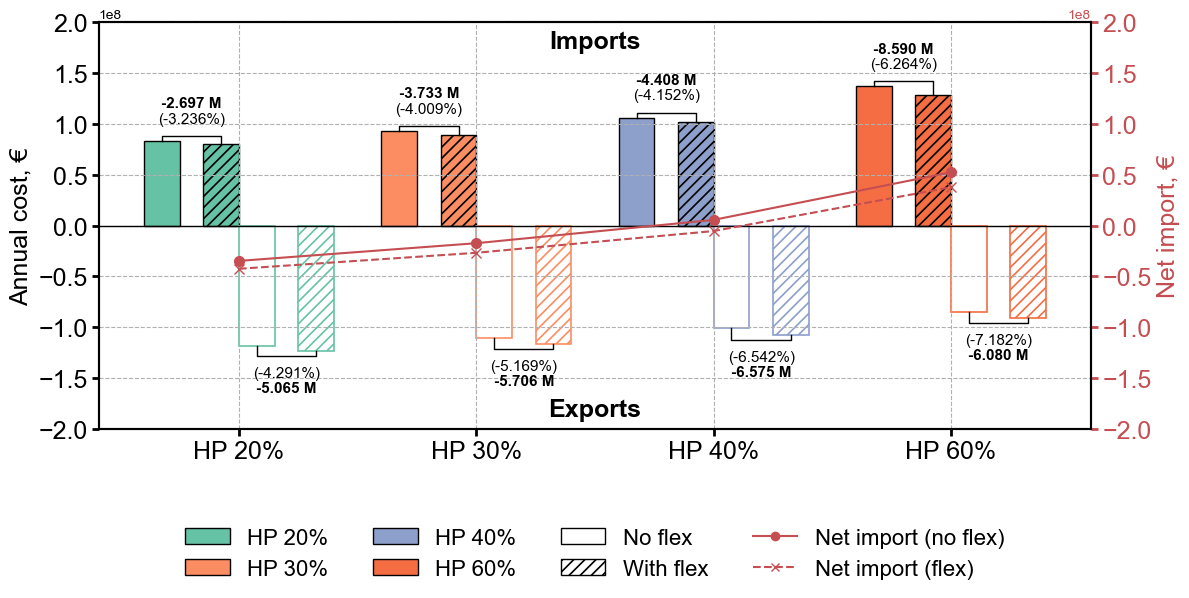

In [8]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 4(h)
# =====================================================================

import pandas as pd
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

mpl.rcParams.update({
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "text.usetex": False,
    "hatch.linewidth": 1.2,
    "hatch.color": "black",
    "patch.force_edgecolor": True,
    "path.simplify": False,
})

# from matplotlib.backends.backend_svg import FigureCanvasSVG
# fig.set_canvas(FigureCanvasSVG(fig))   # Affects only file export and does not modify the display backend
# ========== Tick styling ==========
tick_font_size = 18

def apply_axis_style(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.tick_params(axis='x', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.tick_params(axis='x', labelsize=tick_font_size)

# ========== Scenario mapping ==========
hp_levels = ['HP 20%', 'HP 30%', 'HP 40%', 'HP 60%']
case_mapping = {
    'HP 20%': ('case1a0', 'case1a'),
    'HP 30%': ('case1b0', 'case1b'),
    'HP 40%': ('case1c0', 'case1c'),
    'HP 60%': ('case1d0', 'case1d'),
}

styles = {
    'HP 20%': '#66c2a5',
    'HP 30%': '#fc8d62',
    'HP 40%': '#8da0cb',
    'HP 60%': '#f46d43',
}


# ========== General settings ==========
base_path = r'..\Output_data\power systems results'
x = np.arange(len(hp_levels))
width = 0.3
line_color = '#C44E52'

# Offset constants
offset_line = 5e6
offset_text_delta = 15e6
offset_text_percent = 10e6

# ========== Create figure ==========
fig, ax = plt.subplots(figsize=(12, 5.5))
ax2 = ax.twinx()

# ========== Data processing and plotting ==========
net_nf_list = []
net_flex_list = []

for i, label in enumerate(hp_levels):
    case_nf, case_flex = case_mapping[label]
    color = styles[label]

    path_nf = fr'{base_path}\{case_nf}\national_generation_and_capacity\0-systemcosts_trading_5_an.csv'
    path_flex = fr'{base_path}\{case_flex}\national_generation_and_capacity\0-systemcosts_trading_5_an.csv'
    df_nf = pd.read_csv(path_nf).set_index('Row')
    df_flex = pd.read_csv(path_flex).set_index('Row')

    imp_nf = df_nf.loc['Imports'].iloc[3]
    exp_nf = df_nf.loc['Exports'].iloc[3]
    imp_flex = df_flex.loc['Imports'].iloc[3]
    exp_flex = df_flex.loc['Exports'].iloc[3]

    net_nf = imp_nf + exp_nf
    net_flex = imp_flex + exp_flex
    net_nf_list.append(net_nf)
    net_flex_list.append(net_flex)

    base = x[i]
    gap_outer = 0.10
    bar_width = width / 2

    # Correct the symmetric positions; apply gap_outer to the outermost sides
    offsets = [
        -1.5 * bar_width - gap_outer + bar_width/2 ,  # imp_nf
        -0.5 * bar_width + bar_width/2,              # imp_flex
         0.5 * bar_width + bar_width/2,              # exp_nf
         1.5 * bar_width + gap_outer + bar_width/2   # exp_flex
    ]
    centers = [base + off for off in offsets]

    center_imp_nf, center_imp_flex, center_exp_nf, center_exp_flex = centers

    ax.bar(center_imp_nf - bar_width/2, imp_nf, width=bar_width, color=color, edgecolor='black')
    ax.bar(center_imp_flex - bar_width/2, imp_flex, width=bar_width, color=color, edgecolor='black', hatch='///')
    ax.bar(center_exp_nf - bar_width/2, exp_nf, width=bar_width, color='white', edgecolor=color, linewidth=1.2)
    ax.bar(center_exp_flex - bar_width/2, exp_flex, width=bar_width, color='white', edgecolor=color, hatch='///', linewidth=1.2)

    # ========== Import annotations =====
    delta_imp = imp_flex - imp_nf
    percent_imp = (delta_imp / abs(imp_nf)) * 100 if imp_nf != 0 else 0
    delta_label_imp = f"{delta_imp / 1e6:+.3f} M"
    percent_label_imp = f"({percent_imp:+.3f}%)"

    x1, x2 = center_imp_nf - bar_width/2, center_imp_flex - bar_width/2
    x_mid = (x1 + x2) / 2
    y1, y2 = imp_nf, imp_flex
    y_line = max(y1, y2) + offset_line

    ax.plot([x1, x1, x2, x2], [y1, y_line, y_line, y2], color='black', linewidth=1)
    ax.text(x_mid, y_line + offset_text_percent, percent_label_imp, ha='center', va='bottom', fontsize=11)
    ax.text(x_mid, y_line + offset_text_percent + offset_text_delta, delta_label_imp, ha='center', va='bottom', fontsize=11, fontweight='bold')

    # ========== Export annotations =====
    delta_exp = exp_flex - exp_nf
    percent_exp = (delta_exp / abs(exp_nf)) * 100 if exp_nf != 0 else 0
    delta_label_exp = f"{delta_exp / 1e6:+.3f} M"
    percent_label_exp = f"({percent_exp:+.3f}%)"

    x1, x2 = center_exp_nf - bar_width/2, center_exp_flex - bar_width/2
    x_mid = (x1 + x2) / 2
    y1, y2 = exp_nf, exp_flex
    y_line = min(y1, y2) - offset_line

    ax.plot([x1, x1, x2, x2], [y1, y_line, y_line, y2], color='black', linewidth=1)
    ax.text(x_mid, y_line - offset_text_percent, percent_label_exp, ha='center', va='top', fontsize=11)
    ax.text(x_mid, y_line - offset_text_percent - offset_text_delta, delta_label_exp, ha='center', va='top', fontsize=11, fontweight='bold')

# ========== Net-import line plot ==========
ax2.plot(x, net_nf_list, color=line_color, marker='o', markersize=7, label='Net Import (No Flex)')
ax2.plot(x, net_flex_list, color=line_color, marker='x', linestyle='--', markersize=7, label='Net Import (Flex)')

# ========== Axis settings ==========
ax.set_xticks(x)
ax.set_xticklabels(hp_levels)
ax.set_ylabel('Annual cost, €', fontsize=18)
ax.axhline(y=0, color='black', linewidth=1)
ax.grid(True, linestyle='--', alpha=1)

ax2.set_ylabel('Net import, €', fontsize=18, color=line_color)
ax2.spines['right'].set_color(line_color)
ax2.tick_params(axis='y', colors=line_color)

apply_axis_style(ax)
apply_axis_style(ax2)

# Axis limits
ymin, ymax = -2.0e8, 2.0e8
ax.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)


# ========== Legend ==========
legend_items = [
    Patch(facecolor='#66c2a5', label='HP 20%'),
    Patch(facecolor='#fc8d62', label='HP 30%'),
    Patch(facecolor='#8da0cb', label='HP 40%'),
    Patch(facecolor='#f46d43', label='HP 60%'),
    Patch(facecolor='white', edgecolor='black', hatch=None, label='No flex'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='With flex'),
    plt.Line2D([0], [0], color=line_color, marker='o', linestyle='-', label='Net import (no flex)'),
    plt.Line2D([0], [0], color=line_color, marker='x', linestyle='--', label='Net import (flex)'),
]

ax.text(0.5, 0.98, 'Imports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='top', color='black')
ax.text(0.5, 0.02, 'Exports', transform=ax.transAxes,
        fontsize=18, fontweight='bold', ha='center', va='bottom', color='black')


fig.legend(handles=legend_items,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=4,
           fontsize=16,
           frameon=False)

# ========== Finalize the layout ==========
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ========== Additional step: export as SVG (text remains editable and is not converted to outlines) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Do not use LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ========== plt.show()


### Figure 4(i): Detailed comparison of 2050 electricity prices with and without HP flexibility

This section compares the 2050 electricity price levels under the rigid and flexible HP operation settings for each HP deployment level.


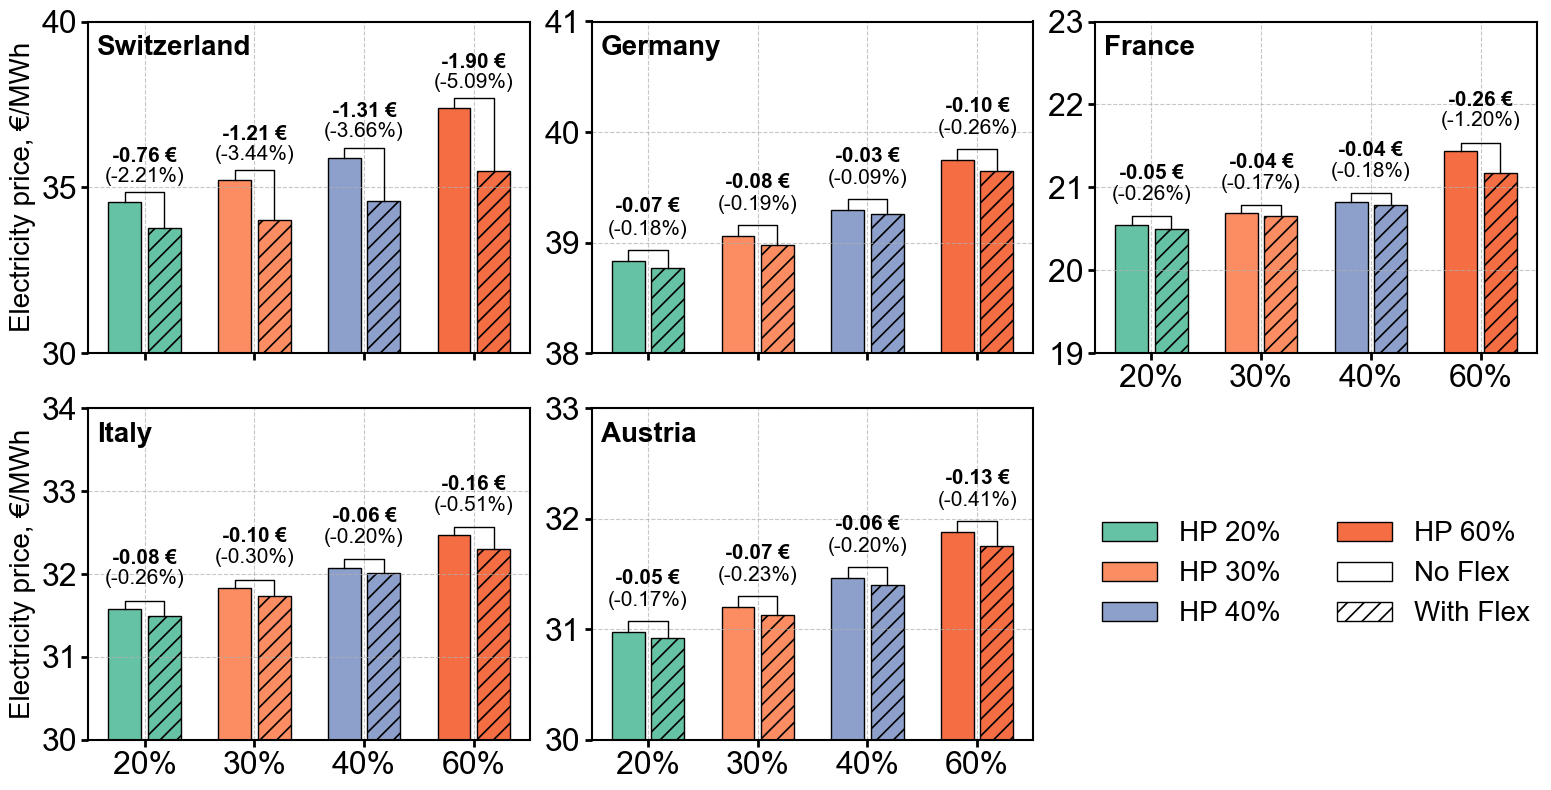

In [9]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 4(i)
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, MaxNLocator
import matplotlib as mpl
from pathlib import Path
# ========== Tick styling ==========
tick_font_size = 23

def apply_axis_style(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.tick_params(axis='x', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.tick_params(axis='x', labelsize=tick_font_size)

# ========== General configuration ==========
hp_levels = ['HP 20%', 'HP 30%', 'HP 40%', 'HP 60%']
hp_levels_short = [s.replace('HP ', '') for s in hp_levels]

case_mapping = {
    'HP 20%': ('case1a0', 'case1a'),
    'HP 30%': ('case1b0', 'case1b'),
    'HP 40%': ('case1c0', 'case1c'),
    'HP 60%': ('case1d0', 'case1d'),
}

styles = {
    'HP 20%': '#66c2a5',
    'HP 30%': '#fc8d62',
    'HP 40%': '#8da0cb',
    'HP 60%': '#f46d43',
}
countries = ['Switzerland', 'Germany', 'France', 'Italy', 'Austria']
ylim_dict = {
    'Switzerland': (30, 40),
    'Germany': (38, 41),
    'France': (19, 23),
    'Italy': (30, 34),
    'Austria': (30, 33),
}
offset_dict = {
    'Switzerland': (0.3, 0.2, 0.6), # offset_line, offset_text_percent, offset_text_delta
    'Germany':     (0.1, 0.1, 0.2),
    'France':      (0.1, 0.15, 0.25),
    'Italy':       (0.1, 0.15, 0.25),
    'Austria':     (0.1, 0.1, 0.2),
}
year_col = '2050'
base_path = r'..\Output_data\power systems results'

# ========== Plotting parameters ==========
x = np.linspace(0, 1.5, len(hp_levels))  # More compact spacing
width = 0.3
gap = 0.03
bar_width = width / 2

# ========== Create figure canvas ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, country in enumerate(countries):
    ax = axes[idx]
    offset_line, offset_text_percent, offset_text_delta = offset_dict[country]

    for i, label in enumerate(hp_levels):
        case_nf, case_flex = case_mapping[label]
        color = styles[label]

        path_nf = fr'{base_path}\{case_nf}\national_generation_and_capacity\0-national_elecprice_annual_c.csv'
        path_flex = fr'{base_path}\{case_flex}\national_generation_and_capacity\0-national_elecprice_annual_c.csv'

        df_nf = pd.read_csv(path_nf).set_index('Row')
        df_flex = pd.read_csv(path_flex).set_index('Row')

        df_nf = df_nf[~df_nf.index.str.lower().str.contains("date")]
        df_flex = df_flex[~df_flex.index.str.lower().str.contains("date")]

        price_nf = float(df_nf.loc[country, year_col])
        price_flex = float(df_flex.loc[country, year_col])

        base = x[i]
        x_nf = base - bar_width / 2 - gap / 2
        x_flex = base + bar_width / 2 + gap / 2

        ax.bar(x_nf, price_nf, width=bar_width, color=color, edgecolor='black', label='No Flex' if i == 0 else None)
        ax.bar(x_flex, price_flex, width=bar_width, color=color, edgecolor='black', hatch='//', label='With Flex' if i == 0 else None)

        delta = price_flex - price_nf
        pct = (delta / price_nf * 100) if price_nf != 0 else 0
        x_mid = (x_nf + x_flex) / 2

        # === Upward offset: fixed value ===
        y_line = price_nf + offset_line
        ax.plot([x_nf, x_nf, x_flex, x_flex],
                [price_nf, y_line, y_line, price_flex],
                color='black', linewidth=1)

        ax.text(x_mid, price_nf + offset_line + offset_text_percent,
                f"({pct:+.2f}%)", ha='center', va='bottom', fontsize=15)

        ax.text(x_mid, price_nf + offset_line + offset_text_percent + offset_text_delta,
                f"{delta:+.2f} €", ha='center', va='bottom', fontsize=15, fontweight='bold')

    # === X-axis: shared across columns ===
    ax.set_xticks(x)
    # Show labels on the second row (idx >= 3, excluding the legend slot 5); keep France visible on the top row as well
    if (idx >= 3 and idx != 5) or country == "France":
        ax.set_xticklabels(hp_levels_short)
    else:
        ax.set_xticklabels([])

    # === Y-axis: Switzerland uses major ticks every 5 units; others use integer ticks ===
    if country == "Switzerland":
        ax.yaxis.set_major_locator(MultipleLocator(5))
    else:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # === Y-axis labels: show only on the left-most subplot of each row ===
    if idx % 3 == 0:
        ax.set_ylabel('Electricity price, €/MWh', fontsize=20)
    else:
        ax.set_ylabel(None)

    ax.set_ylim(ylim_dict[country])
    ax.axhline(y=0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.7)
    apply_axis_style(ax)

    ax.text(0.02, 0.96, country,
            transform=ax.transAxes,
            fontsize=20, fontweight='bold',
            verticalalignment='top',
            horizontalalignment='left')

# ========== Legend (the sixth subplot) ==========
legend_ax = axes[5]
legend_ax.axis('off')
legend_items = [
    Patch(facecolor=styles[label], edgecolor='black', label=label) for label in hp_levels
] + [
    Patch(facecolor='white', edgecolor='black', label='No Flex'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='With Flex'),
]
legend_ax.legend(handles=legend_items,
                 loc='center',
                 fontsize=20,
                 ncol=2,
                 frameon=False)

plt.tight_layout()
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ======================= SVG export for editable text in Adobe Illustrator =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX rendering to avoid text-to-path conversion
mpl.rcParams['font.family'] = ['Arial']

# # Output path (modify if needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save the figure as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()



### Figure 4(j): Renewable curtailment by technology and compare total curtailment changes across countries

This code cell loads annual curtailment results for multiple heat pump penetration scenarios, compares the cases with and without flexible HP operation, and visualizes the differences.

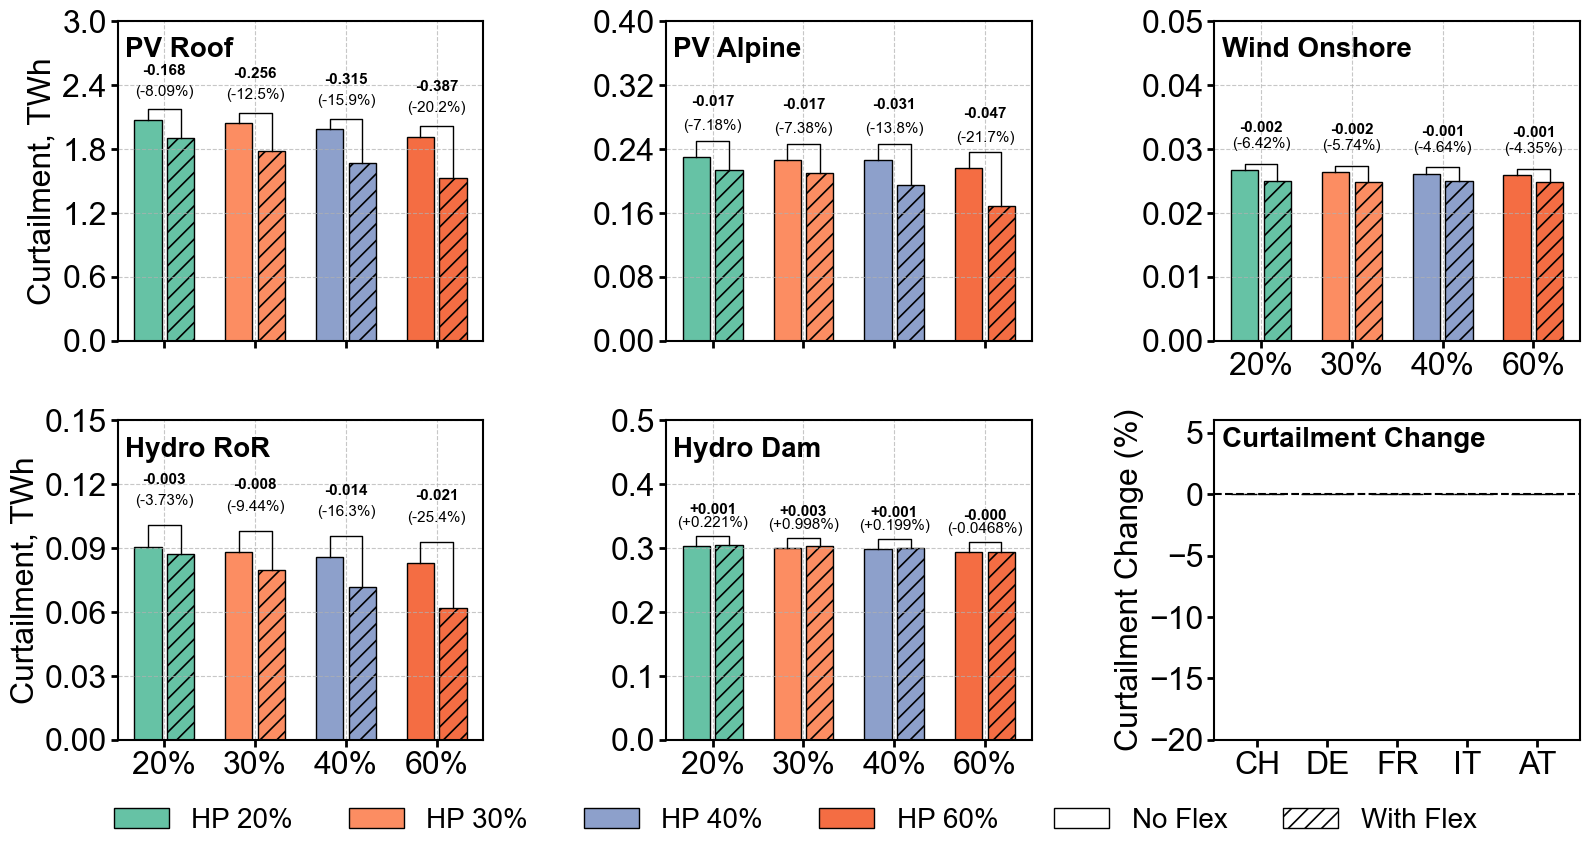

In [10]:
# =====================================================================
# This cell analyses and visualizes the results as shown in Figure 4(j)
# =====================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl
from pathlib import Path

# ---- Configuration ----
countries = {
    'ch': 'Switzerland',
    'de': 'Germany',
    'fr': 'France',
    'it': 'Italy',
    'at': 'Austria'
}
techs = ['PV Roof','PV Alpine' , 'Wind Onshore', 'Hydro RoR', 'Hydro Dam']
base_path = r'..\Output_data\power systems results'

cases_nf   = {'HP 20%': 'case1a0', 'HP 30%': 'case1b0', 'HP 40%': 'case1c0', 'HP 60%': 'case1d0'}
cases_flex = {'HP 20%': 'case1a',  'HP 30%': 'case1b',  'HP 40%': 'case1c',  'HP 60%': 'case1d'}
hp_levels = list(cases_nf.keys())
# Match the electricity price figure style by removing the 'HP ' prefix from the x-axis labels
hp_levels_short = [s.replace('HP ', '') for s in hp_levels]


styles = {
    'HP 20%': {'color': '#66c2a5'},
    'HP 30%': {'color': '#fc8d62'},
    'HP 40%': {'color': '#8da0cb'},
    'HP 60%': {'color': '#f46d43'}
}

tick_font_size = 23
label_font_size = 23
use_full_names = False  # Whether to use full country names for x-axis labels (False = abbreviations)

# Y-axis limits for each technology-specific subplot
ylim_dict = {
    'PV Alpine': (0, 0.4),
    'Hydro Dam': (0, 0.5),
    'Wind Onshore': (0, 0.05),
    'Hydro RoR': (0, 0.15),
    'PV Roof': (0, 3.0)
}
# Annotation offsets for connector lines, delta labels, and percentage labels
text_offset_dict = {
    'PV Alpine': (0.02, 0.03, 0.01),
    'Hydro Dam': (0.015, 0.02, 0.01),
    'Wind Onshore': (0.001, 0.0025, 0.002),
    'Hydro RoR': (0.01, 0.01, 0.008),
    'PV Roof': (0.1, 0.2, 0.1)
}

# Y-axis limits for the sixth subplot (percentage change)
ylim_total = (-20, 6)  # Adjust as needed

def apply_axis_style(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.tick_params(axis='x', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', which='major', pad=3, width=2, length=5)
    ax.tick_params(axis='y', labelsize=tick_font_size)
    ax.tick_params(axis='x', labelsize=tick_font_size)

# ---- Plotting ----
# Create a 2x3 figure: five technology-specific panels and one summary comparison panel.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

bar_width = 0.3
gap = 0.03
bar_width_half = bar_width / 2
x = np.linspace(0, 1.5, len(hp_levels))
target_country = 'ch'

# First five subplots: curtailment by technology in Switzerland
for t_idx, tech in enumerate(techs):
    ax = axes[t_idx]
    offset_line, offset_delta, offset_percent = text_offset_dict[tech]
    ylim = ylim_dict[tech]

    for i, hp in enumerate(hp_levels):
        path_nf = fr'{base_path}\{cases_nf[hp]}\national_generation_and_capacity\0-national_curtailment_annual_c_{target_country}.csv'
        path_flex = fr'{base_path}\{cases_flex[hp]}\national_generation_and_capacity\0-national_curtailment_annual_c_{target_country}.csv'

        df_nf = pd.read_csv(path_nf, index_col=0)
        df_flex = pd.read_csv(path_flex, index_col=0)

        val_nf = df_nf.loc[tech, '2050'] if tech in df_nf.index else 0
        val_flex = df_flex.loc[tech, '2050'] if tech in df_flex.index else 0

        base = x[i]
        x_nf = base - bar_width_half / 2 - gap / 2
        x_flex = base + bar_width_half / 2 + gap / 2
        color = styles[hp]['color']

        ax.bar(x_nf,   val_nf,   width=bar_width_half, color=color, edgecolor='black')
        ax.bar(x_flex, val_flex, width=bar_width_half, color=color, edgecolor='black', hatch='//')

        delta = val_flex - val_nf
        pct = (delta / val_nf * 100) if val_nf != 0 else 0
        x_mid = (x_nf + x_flex) / 2
        y_line = val_nf + offset_line

        ax.plot([x_nf, x_nf, x_flex, x_flex], [val_nf, y_line, y_line, val_flex], color='black', linewidth=1)
        ax.text(x_mid, y_line + offset_percent,                f"({pct:+.3}%)", ha='center', va='bottom', fontsize=11)
        ax.text(x_mid, y_line + offset_percent + offset_delta, f"{delta:+.3f}",  ha='center', va='bottom', fontsize=11, fontweight='bold')

    # ---- Axis formatting and labeling ---- #
    # X-axis: show labels for the bottom row and for the Wind Onshore panel in the top row
    ax.set_xticks(x)
    if t_idx >= 3 or tech == "Wind Onshore":
        ax.set_xticklabels(hp_levels_short)
    else:
        ax.set_xticklabels([])

    # Y-axis: show the ylabel only on the leftmost subplot of each row while keeping tick marks on all panels
    if t_idx % 3 == 0:
        ax.set_ylabel('Curtailment, TWh', fontsize=label_font_size)
    else:
        ax.set_ylabel(None)

    # Reduce y-axis tick density to improve readability (at most 5 major ticks)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # Other formatting settings
    ax.set_ylim(ylim)
    ax.axhline(y=0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.7)
    apply_axis_style(ax)

    # Subplot title in the upper-left corner
    ax.text(0.02, 0.95, tech, transform=ax.transAxes, fontsize=20, fontweight='bold',
            ha='left', va='top')

# Sixth subplot: percentage change in total curtailment across countries (flex vs. no-flex)
ax_total = axes[-1]
x_cty = np.arange(len(countries))
bar_width = 0.18
gap = 0.02

for i, hp in enumerate(hp_levels):
    pct_vals = []
    for c_code in countries:
        path_nf = fr'{base_path}\{cases_nf[hp]}\national_generation_and_capacity\national_curtailment_annual_c_{c_code}.csv'
        path_flex = fr'{base_path}\{cases_flex[hp]}\national_generation_and_capacity\national_curtailment_annual_c_{c_code}.csv'

        val_nf, val_flex = 0, 0

        if os.path.exists(path_nf):
            df_nf = pd.read_csv(path_nf, index_col=0)
            val_nf = sum(df_nf.loc[t, '2050'] if t in df_nf.index else 0 for t in techs)

        if os.path.exists(path_flex):
            df_flex = pd.read_csv(path_flex, index_col=0)
            val_flex = sum(df_flex.loc[t, '2050'] if t in df_flex.index else 0 for t in techs)

        pct_change = ((val_flex - val_nf) / val_nf * 100) if val_nf != 0 else 0
        pct_vals.append(pct_change)

    x_pos = x_cty + (i - 1.5) * (bar_width + gap / 2)
    ax_total.bar(x_pos, pct_vals, width=bar_width, color=styles[hp]['color'], edgecolor='black', hatch='//')

ax_total.axhline(y=0, color='black', linestyle='--')
ax_total.set_xticks(x_cty)
xtick_labels = [countries[c] if use_full_names else c.upper() for c in countries]
ax_total.set_xticklabels(xtick_labels)
ax_total.set_ylabel('Curtailment Change (%)', fontsize=label_font_size)
ax_total.text(0.02, 0.98, 'Curtailment Change', transform=ax_total.transAxes,
              fontsize=20, fontweight='bold', ha='left', va='top')
ax_total.yaxis.set_major_locator(MaxNLocator(nbins=6))  # Allow a slightly wider tick range for the summary panel
apply_axis_style(ax_total)

# Apply the custom y-axis range
if ylim_total:
    ax_total.set_ylim(ylim_total)

plt.tight_layout()

# ---- Legend (colors indicate HP levels; hatching indicates flexibility) ----
legend_hp = [Patch(facecolor=styles[hp]['color'], edgecolor='black', label=hp) for hp in hp_levels]
legend_style = [
    Patch(facecolor='white', edgecolor='black', label='No Flex'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='With Flex')
]
fig.legend(
    handles=legend_hp + legend_style,
    loc='lower center',
    ncol=6,
    fontsize=20,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()

# Use more compact spacing between subplots
plt.subplots_adjust(
    wspace=0.5, # Horizontal spacing between subplots
    hspace=0.25  # Vertical spacing between subplots
)
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
# ======================= SVG export for editable text in Adobe Illustrator =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Avoid LaTeX rendering so the text is not converted to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Output path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()

